وقتی داده ها فیلتر شدند این برنامه نمودار تولید بر اساس دما را برای تمام واحدهای تولیدی رسم کرده و داده های مربوط به آخرین سری تولید و داده های انتخاب شده توسط فیلتر پنجم را نیز مشخص میکند. 

In [1]:
import os
import sys

import pandas as pd
import plotly.graph_objects as go

import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *

In [4]:
l_min = 4
max_diff = 3
c_thresh = 0.9
temp_feature = "humidity"
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
df_c = df

In [5]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)

coefs = {}
grouped = df_factors.groupby(['PowerPlantCode', 'PowerPlantName', "UnitCode"])

for (pp_code, pp_name, unit_code), g in grouped:
    uniques = g[["a1IndexGas", "b1IndexGas"]].drop_duplicates()
    coefs[(pp_name, unit_code)] = []
    for row in uniques.itertuples(index=False):
        coefs[(pp_name, unit_code)].append((row.a1IndexGas, row.b1IndexGas))

In [6]:
def select_envelope_neighbors_indices(X, y, one_unit_df, temp_feature, alpha, beta):
    # model = LinearRegression()#PolynomialModel(degree=2)
    # model.fit(X, y)
    
    model = RANSACRegressor(estimator=LinearRegression(), min_samples=0.9)

    sens_temps = one_unit_df[temp_feature].values
    gens = one_unit_df['generation'].values
    
    model.fit(X, y)
    X_all = sens_temps.reshape(-1, 1)
    y_pred_all = model.predict(X_all)
    is_in_area = (y_pred_all + alpha >= gens) & (gens >= y_pred_all - beta)
    return model

In [11]:
import plotly.express as px


def show(df_m1, save=False, param=None, ass=""):
    features = ["name", "code", "generation", f"{temp_feature}", "is_good_peak"]
    df_modified = df_m1[features].copy(deep=True)
    df_modified = df_modified[df_modified["is_good_peak"] >= 5]
    ds = Data_selector(df_modified)

    name, code = param['name'], param['code']
    one_unit_df = ds.filter_name_code(name, code)

    sens_temps = one_unit_df[temp_feature].values
    gens = one_unit_df['generation'].values

    X, y = find_points_on_envelope(gens, sens_temps, bin_length=100, p=0.95)

    model = select_envelope_neighbors_indices(X, y, one_unit_df,temp_feature, alpha=2,beta=5)
    y_pred_model = model.predict(X)
    
    fig = px.scatter(df_m1, x="datetime", y='generation', color='is_good_peak',
                     title='Generation over Time by Batch Interval',
                     labels={'generation': 'Generation', 'datetime': 'Time'},
                     hover_data=['datetime', 'generation', temp_feature])

    if save:
        fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter5{ass}/{param['name']}-{param['code']}_l.html")
    else:
        fig.show()

    fig = px.scatter(df_m1, x=temp_feature, y='generation', color='is_good_peak',
                     title='Generation over Time by Batch Interval',
                     labels={'generation': 'Generation'},
                     hover_data=['datetime', 'generation', temp_feature],size_max=1)
    
    fig.update_traces(
    marker=dict(
        size=4,           # اندازه ثابت
        sizemode='diameter',  # یا 'area'
        sizeref=1,        # برای مقیاس‌بندی
        opacity=0.7       # شفافیت
    )
    )
    
    n = param["name"]
    c = param["code"]
    for i in range(0):#(len(coefs[(n, c)])):
        a, b = coefs[(n, c)][i]
        x_line = np.linspace(df_m1[temp_feature].min(), df_m1[temp_feature].max(), 100)
        y_line = a * x_line + b
        
        fig.add_trace(go.Scatter(
            x=x_line,
            y=y_line,
            mode="lines",
            name=f"y = {a}x + {b}",
            line=dict(dash="dash", width=2)
        ))
    
    df_points = pd.DataFrame({
    'sens_temp': X.flatten(),
    'generation_env': y,
    "y_pred_model" : y_pred_model
    })
    
    # اضافه کردن نقاط envelope (به صورت scatter دوم)
    fig.add_scatter(
        x=df_points['sens_temp'], 
        y=df_points['generation_env'], 
        mode='markers', 
        marker=dict(size=10, color='black'),
        name='Envelope Points'
    )
    
    fig.add_trace(go.Scatter(
            x=df_points['sens_temp'],
            y=df_points['y_pred_model'],
            mode="lines",
            line=dict(dash="solid", width=2)
        ))
    
    
    fig.add_trace(go.Scatter(
            x=df_points['sens_temp'],
            y=df_points['y_pred_model']-5,
            mode="lines",
            line=dict(dash="solid", width=2)
        ))
    
    
    fig.add_trace(go.Scatter(
            x=df_points['sens_temp'],
            y=df_points['y_pred_model']+2,
            mode="lines",
            line=dict(dash="solid", width=2)
        ))
    
    if save:
        fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter5{ass}/{param['name']}-{param['code']}_s.html")
    else:
        fig.show()
        
    return X,y
        
    

In [10]:
power_plants = df_c[['name', 'code']].drop_duplicates()

for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=2))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    try:
        show(df_n_c_plot, save=True, param={"name": name_plot, "code": code_plot})
    except:
        print(name_plot,code_plot)

U:\ML_project\Bargh_ML\venv\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.



In [14]:
def new_predict(X,model1,model2,t_c):
    y1 = model1.predict(X.reshape(-1,1))
    y2 = model2.predict(X.reshape(-1,1))
    mask = X < t_c
    return np.where(mask, y1, y2)

In [39]:
def get_Xy(df_c,name_plot,code_plot):
    ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=3))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    print(name_plot,code_plot,int(len(df_n_c_plot)/(365*24)*10)/10)
    try:
        X,y = show(df_n_c_plot, save=True, param={"name": name_plot, "code": code_plot})
    except:
        print("None")
        return None,None
    return X,y

def get_acc(X,y,t_c,model,th=None,cum=False):
    
    X = X.flatten()
    y_i = y[X > t_c]
    X_i = X[X > t_c]
    
    model.fit(X_i.reshape(-1,1),y_i)
    y_i_pred_1 = model.predict(X_i.reshape(-1,1))
    err = utils.compute_r2_score(y_i_pred_1,y_i)
    if (th and err > th):
        plt.scatter(X_i,y_i,s=1)
        #plt.plot(X_i,y_i_pred_1)
        plt.grid()
        plt.show()
    elif cum:
        plt.scatter(X_i,y_i,s=1)
        #plt.plot(X_i,y_i_pred_1)
        plt.grid() 
    return err
    
    model2.fit(X_i.reshape(-1,1),y_i)
    y_i_pred_2 = model2.predict(X_i.reshape(-1,1))
    
    
    y_pred_1 = model1.predict(X.reshape(-1,1))
    y_pred_2 = model2.predict(X.reshape(-1,1))
    y_pred_3 = new_predict(X,model1,model2,t_c)
    
    e1 = utils.compute_relative_rmse(y_pred_1,y)
    e2 = utils.compute_relative_rmse(y_pred_2,y)
    e3 = utils.compute_relative_rmse(y_pred_3,y)
    
    return e1,e2,e3

In [16]:
name_plot = "حافظ"
code_plot = "G11"
time = pd.Timestamp('2020-01-01')
ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=3))
df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
try:
    X,y = show(df_n_c_plot, save=True, param={"name": name_plot, "code": code_plot})
except:
    print(name_plot,code_plot)

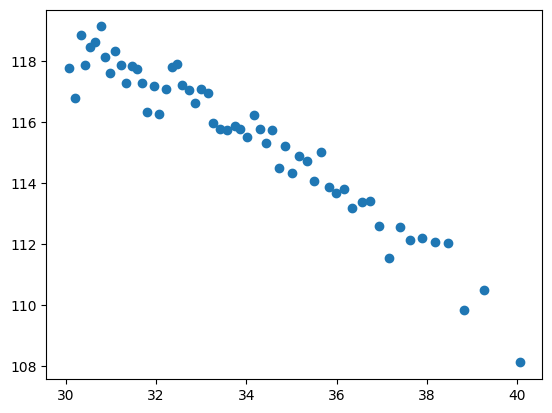

In [17]:
X = X.flatten()
t_c = 30
y_i = y[X>t_c] 
X_i = X[X>t_c]
plt.scatter(X_i,y_i)

In [18]:
model1 = LinearRegression()
model1.fit(X_i.reshape(-1,1),y_i)
y_i_pred_1 = model1.predict(X_i.reshape(-1,1))

In [19]:
model2 = PolynomialModel(degree=2)
model2.fit(X_i.reshape(-1,1),y_i)
y_i_pred_2 = model2.predict(X_i.reshape(-1,1))

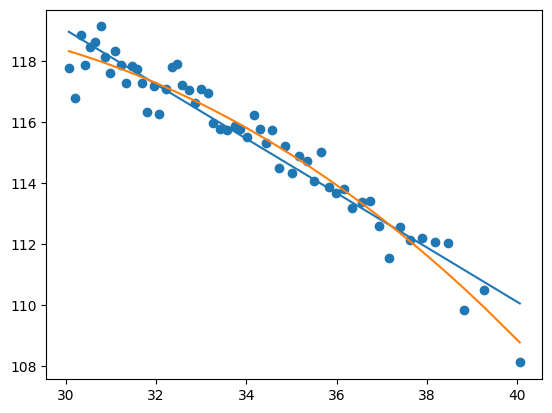

In [20]:
plt.scatter(X_i,y_i)
plt.plot(X_i,y_i_pred_1)
plt.plot(X_i,y_i_pred_2)
plt.show()

In [21]:
from src.models import utils
print("error linear :", utils.compute_relative_rmse(y_i_pred_1, y_i))
print("error custom :", utils.compute_relative_rmse(y_i_pred_2, y_i))

error linear : 0.561930139163787
error custom : 0.4657074145251643


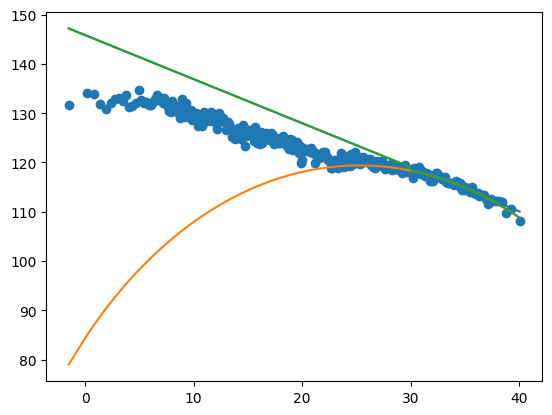

In [22]:
y_pred_1 = model1.predict(X.reshape(-1,1))
y_pred_2 = model2.predict(X.reshape(-1,1))
y_pred_3 = new_predict(X,model1,model2,t_c)
plt.scatter(X,y,label="actual")
plt.plot(X,y_pred_1,label="model_linear")
plt.plot(X,y_pred_2,label="model_custom")
plt.plot(X,y_pred_3,label="model_newwww")
plt.show()

In [23]:
print("error linear :",utils.compute_relative_rmse(y_pred_1,y))
print("error custom :",utils.compute_relative_rmse(y_pred_2,y))
print("error new :",utils.compute_relative_rmse(y_pred_3,y))

error linear : 4.3672356610221925
error custom : 11.76894046963403
error new : 4.36524398157657


In [24]:
Xy_by_name_code = {}
for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    X,y = get_Xy(df_c,name_plot,code_plot)
    Xy_by_name_code[(name_plot,code_plot)] = X,y

جنوب اصفهان - چهلستون G11 3.1
جنوب اصفهان - چهلستون G12 1.3
جنوب اصفهان - چهلستون G13 1.1
جنوب اصفهان - چهلستون G14 1.0
جنوب اصفهان - چهلستون G15 1.0
جنوب اصفهان - چهلستون G16 1.2
حافظ G11 3.3
حافظ G12 1.2
حافظ G13 1.1
حافظ G14 1.2
حافظ G15 1.2
حافظ G16 1.2
سبلان G11 2.6
سبلان G12 1.1
سبلان G13 0.7
سبلان G14 0.2
سبلان G15 0.9
سبلان G16 0.9
سیکل ترکیبی ارومیه G11 2.1
سیکل ترکیبی ارومیه G12 1.3
سیکل ترکیبی ارومیه G13 1.1
سیکل ترکیبی ارومیه G14 1.2
سیکل ترکیبی ارومیه G15 1.0
سیکل ترکیبی ارومیه G16 1.0
سیکل ترکیبی شیروان G11 3.0
سیکل ترکیبی شیروان G12 1.1
سیکل ترکیبی شیروان G13 1.2
سیکل ترکیبی شیروان G14 1.2
سیکل ترکیبی شیروان G15 0.9
سیکل ترکیبی شیروان G16 0.9
سیکل ترکیبی یزد G11 1.7
سیکل ترکیبی یزد G12 0.8
سیکل ترکیبی یزد G13 0.0


U:\ML_project\Bargh_ML\venv\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.



سیکل ترکیبی یزد G14 0.2
سیکل ترکیبی یزد G15 0.3
سیکل ترکیبی یزد G16 1.2
شهدای پاکدشت - دماوند G11 3.2
شهدای پاکدشت - دماوند G12 1.2
شهدای پاکدشت - دماوند G13 0.5
شهدای پاکدشت - دماوند G14 1.1
شهدای پاکدشت - دماوند G15 1.1
شهدای پاکدشت - دماوند G16 1.2
شهدای پاکدشت - دماوند G17 1.2
شهدای پاکدشت - دماوند G18 1.3
شهدای پاکدشت - دماوند G19 1.2
شهدای پاکدشت - دماوند G20 1.0
شهدای پاکدشت - دماوند G21 1.2
شهدای پاکدشت - دماوند G22 0.1
شهدای پیروز - بهبهان G11 3.4
شهدای پیروز - بهبهان G12 1.3
عسلویه G11 1.4
عسلویه G12 0.4
عسلویه G13 1.2
عسلویه G14 1.2
عسلویه G15 1.1
عسلویه G16 1.2
قم G11 3.0
قم G12 1.0
قم G13 1.2
قم G14 1.3
پرند G11 2.7
پرند G12 0.2
پرند G13 1.3
پرند G14 1.3
پرند G15 1.2
پرند G16 1.2
گیلان G11 3.3
گیلان G12 1.2
گیلان G13 1.1
گیلان G14 1.2
گیلان G15 0.3
گیلان G16 1.1


In [ ]:
def show():

U:\ML_project\Bargh_ML\venv\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.



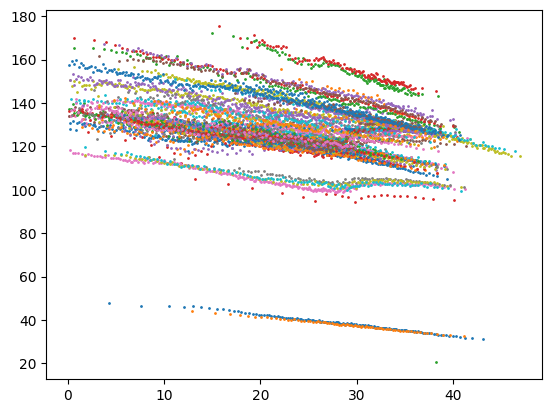

In [40]:
t_c = 0
power_plants = df_c[['name', 'code']].drop_duplicates()
errs = {}
th = 1
for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    X,y = Xy_by_name_code[(name_plot,code_plot)]
    err = get_acc(X,y,t_c,model = LinearRegression(),th=None,cum=True)
    if err > th:
        print(name_plot,code_plot)
        print(err)
    errs[(name_plot,code_plot)] = err
plt.show()

(array([ 4.,  3.,  5.,  3.,  0.,  2.,  2.,  3.,  1.,  0.,  1.,  0.,  0.,
         1.,  0.,  1.,  0.,  7., 13., 25.]),
 array([2.63822471e-05, 4.97159386e-02, 9.94054949e-02, 1.49095051e-01,
        1.98784608e-01, 2.48474164e-01, 2.98163720e-01, 3.47853276e-01,
        3.97542833e-01, 4.47232389e-01, 4.96921945e-01, 5.46611502e-01,
        5.96301058e-01, 6.45990614e-01, 6.95680171e-01, 7.45369727e-01,
        7.95059283e-01, 8.44748840e-01, 8.94438396e-01, 9.44127952e-01,
        9.93817509e-01]),
 <BarContainer object of 20 artists>)

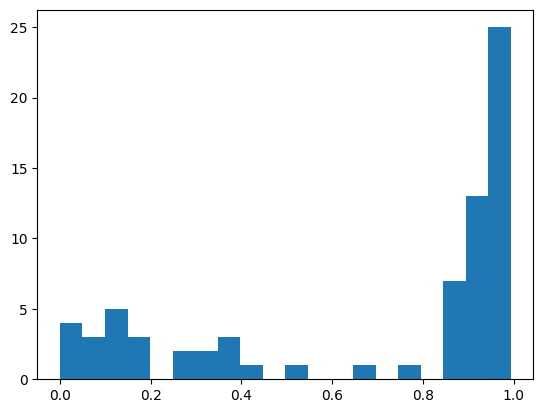

In [216]:
asd = np.array([errs[k] for k in errs])
plt.hist(asd,bins=20)

In [222]:
len(asd[asd<0.9])

34

جنوب اصفهان - چهلستون G11 3.1
جنوب اصفهان - چهلستون G12 1.3
جنوب اصفهان - چهلستون G13 1.1
جنوب اصفهان - چهلستون G14 1.0
جنوب اصفهان - چهلستون G15 1.0
جنوب اصفهان - چهلستون G16 1.2
حافظ G11 3.3
حافظ G12 1.2
حافظ G13 1.1
حافظ G14 1.2
حافظ G15 1.2
حافظ G16 1.2
سبلان G11 2.6
سبلان G12 1.1
سبلان G13 0.7
سبلان G14 0.2
سبلان G15 0.9
سبلان G16 0.9
سیکل ترکیبی ارومیه G11 2.1
سیکل ترکیبی ارومیه G12 1.3
سیکل ترکیبی ارومیه G13 1.1
سیکل ترکیبی ارومیه G14 1.2
سیکل ترکیبی ارومیه G15 1.0
سیکل ترکیبی ارومیه G16 1.0
سیکل ترکیبی شیروان G11 3.0
سیکل ترکیبی شیروان G12 1.1
سیکل ترکیبی شیروان G13 1.2
سیکل ترکیبی شیروان G14 1.2
سیکل ترکیبی شیروان G15 0.9
سیکل ترکیبی شیروان G16 0.9
سیکل ترکیبی یزد G11 1.7
سیکل ترکیبی یزد G12 0.8
سیکل ترکیبی یزد G13 0.0


U:\ML_project\Bargh_ML\venv\Lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning:

R^2 score is not well-defined with less than two samples.



سیکل ترکیبی یزد G14 0.2
سیکل ترکیبی یزد G15 0.3
سیکل ترکیبی یزد G16 1.2
شهدای پاکدشت - دماوند G11 3.2
شهدای پاکدشت - دماوند G12 1.2
شهدای پاکدشت - دماوند G13 0.5
شهدای پاکدشت - دماوند G14 1.1
شهدای پاکدشت - دماوند G15 1.1
شهدای پاکدشت - دماوند G16 1.2
شهدای پاکدشت - دماوند G17 1.2
شهدای پاکدشت - دماوند G18 1.3
شهدای پاکدشت - دماوند G19 1.2
شهدای پاکدشت - دماوند G20 1.0
شهدای پاکدشت - دماوند G21 1.2
شهدای پاکدشت - دماوند G22 0.1
شهدای پیروز - بهبهان G11 3.4
شهدای پیروز - بهبهان G12 1.3
عسلویه G11 1.4
عسلویه G12 0.4
عسلویه G13 1.2
عسلویه G14 1.2
عسلویه G15 1.1
عسلویه G16 1.2
قم G11 3.0
قم G12 1.0
قم G13 1.2
قم G14 1.3
پرند G11 2.7
پرند G12 0.2
پرند G13 1.3
پرند G14 1.3
پرند G15 1.2
پرند G16 1.2
گیلان G11 3.3
گیلان G12 1.2
گیلان G13 1.1
گیلان G14 1.2
گیلان G15 0.3
گیلان G16 1.1


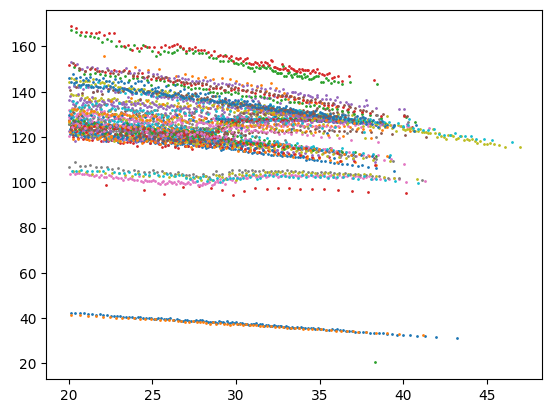

In [198]:
t_c = 20
power_plants = df_c[['name', 'code']].drop_duplicates()
for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    X,y = get_Xy(df_c,name_plot,code_plot)
    get_acc(X,y,t_c,cum=True)
plt.show()
    